# Import Libraries 

In [1]:
import ee


print("Authenticating with Google Earth Engine...")
ee.Authenticate()

print("Initializing project...")
ee.Initialize(project="agriculture-drought-assesment")

Authenticating with Google Earth Engine...
Initializing project...


In [137]:
import importlib

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from data import indices, load_CHIRPS, load_ERA5, load_S2, utils
from visualisation import index_plotter
from features import engineering

importlib.reload(indices)
importlib.reload(load_S2)
importlib.reload(load_ERA5)
importlib.reload(load_CHIRPS)
importlib.reload(utils)
importlib.reload(index_plotter)
importlib.reload(engineering)

<module 'features.engineering' from '/home/luke/projects/agriculture-analysis/src/features/engineering.py'>

# Prepare DataFrames

In [3]:
region = utils.get_region()
i_date = "2021-01-01"
f_date = "2024-12-31"

In [88]:

    print(f"Loading Sentinel-2 dataset for periods {i_date} to {f_date}...")
    s2_clouded = load_S2.get_s2_data(region, i_date, f_date)

    print(f"Loading ERA5 Land data for periods {i_date} to {f_date}...")
    era5_data = load_ERA5.get_era5_data(region, i_date, f_date)

    print(f"Loading CHIRPS Climate Data for periods {i_date} to {f_date}...")
    chirps_data = load_CHIRPS.get_chirps_data(region, i_date, f_date)

    s2_clear_sky = s2_clouded.map(load_S2.s2_clear_sky)

    reducer_fn = utils.create_reducer(region, scale=10)
    ndvi_df = indices.get_index_df(s2_clear_sky, indices.NDVI, reducer_fn)
    ndre_df = indices.get_index_df(s2_clear_sky, indices.NDRE, reducer_fn)
    ndwi_df = indices.get_index_df(s2_clear_sky, indices.NDWI, reducer_fn)

    reducer_fn = utils.create_reducer(region, scale=20)
    slvw_df = load_ERA5.get_soil_levels_df(era5_data, reducer_fn, "water")
    slt_df = load_ERA5.get_soil_levels_df(era5_data, reducer_fn, "temp")
    temp_2m_df = load_ERA5.get_temp_2m_df(era5_data, reducer_fn)
    ssrd_df = load_ERA5.get_ssrd(era5_data, reducer_fn)

    reducer_fn = utils.create_reducer(region, scale=5566)
    perc_df = load_CHIRPS.get_precipitation_df(chirps_data, reducer_fn)

    grouped = indices.apply_groupby_date(ndwi_df, ndvi_df, ndre_df)
    ndwi_df_grouped = grouped[0]
    ndvi_df_grouped = grouped[1]
    ndre_df_grouped = grouped[2]

    master_df = utils.merge_with_master(
        ndvi_df_grouped,
        ndwi_df_grouped,
        ndre_df_grouped,
        slvw_df,
        slt_df,
        temp_2m_df,
        ssrd_df,
        perc_df,
    )
    print("Done!")



Loading Sentinel-2 dataset for periods 2021-01-01 to 2024-12-31...
Loading ERA5 Land data for periods 2021-01-01 to 2024-12-31...
Loading CHIRPS Climate Data for periods 2021-01-01 to 2024-12-31...
Creating NDVI DataFrame...
Creating NDRE DataFrame...
Creating NDWI DataFrame...
Creating volumetric_soil_water_layer_1 DataFrame...
Creating volumetric_soil_water_layer_2 DataFrame...
Creating volumetric_soil_water_layer_3 DataFrame...
Creating volumetric_soil_water_layer_4 DataFrame...
Concatinated water levels DataFrame.
Creating soil_temperature_level_1 DataFrame...
Creating soil_temperature_level_2 DataFrame...
Creating soil_temperature_level_3 DataFrame...
Creating soil_temperature_level_4 DataFrame...
Concatinated temp levels DataFrame.
Creating temperature_2m DataFrame...
Creating surface_solar_radiation_downwards_sum DataFrame...
Creating precipitation DataFrame...
Done!


In [94]:
non_spectral_df = utils.merge_with_master(slvw_df, slt_df, temp_2m_df, ssrd_df, perc_df)
non_spectral_df.to_csv("non_spectral_df.csv")

In [95]:
spectral_df = utils.merge_with_master(ndvi_df, ndwi_df, ndre_df)
spectral_df.to_csv("spectral_df.csv")

In [91]:
grouped = indices.apply_groupby_date(ndwi_df, ndvi_df, ndre_df)
ndwi_df_grouped = grouped[0]
ndvi_df_grouped = grouped[1]
ndre_df_grouped = grouped[2]


In [96]:
grouped_spectral_df = utils.merge_with_master(ndvi_df_grouped, ndwi_df_grouped, ndre_df_grouped)
grouped_spectral_df.to_csv("grouped_spectral_df.csv")

In [3]:
non_spectral_df = pd.read_csv("non_spectral_df.csv", index_col=0)
non_spectral_df["Timestamp"] = pd.to_datetime(non_spectral_df["Timestamp"])
spectral_df = pd.read_csv("spectral_df.csv", index_col=0)
spectral_df["Timestamp"] = pd.to_datetime(spectral_df["Timestamp"])
grouped_spectral_df = pd.read_csv("grouped_spectral_df.csv", index_col=0)
grouped_spectral_df["Timestamp"] = pd.to_datetime(grouped_spectral_df["Timestamp"])

In [5]:
master_df = utils.merge_with_master(grouped_spectral_df, non_spectral_df)
master_df.head()

,Timestamp,NDVI_mean,NDVI_std,NDWI_mean,NDWI_std,NDRE_mean,NDRE_std,volumetric_soil_water_layer_1,volumetric_soil_water_layer_2,volumetric_soil_water_layer_3,volumetric_soil_water_layer_4,soil_temperature_level_1,soil_temperature_level_2,soil_temperature_level_3,soil_temperature_level_4,temperature_2m,surface_solar_radiation_downwards_sum,precipitation
0,2021-02-10,0.673053,0.028794,0.440118,0.042311,0.453268,0.040651,0.462551,0.448877,0.466825,0.300550,294.069889,293.548100,292.099834,291.449413,291.738612,2.222716e+07,27.658445
1,2021-02-20,0.654526,0.033826,0.382090,0.038691,0.453253,0.040155,0.358619,0.392014,0.434314,0.305685,293.022377,293.184996,292.514029,291.599089,292.496838,2.991418e+07,0.000000
2,2021-03-02,0.594535,0.014670,0.368082,0.021772,0.398210,0.022341,0.404106,0.425275,0.420446,0.307468,291.241525,291.304370,291.940702,291.704808,289.210858,2.428342e+07,0.000000
3,2021-03-07,0.626770,0.029061,0.335441,0.029934,0.439704,0.029284,0.342668,0.378511,0.408774,0.307995,291.952316,292.235655,292.064194,291.723281,291.937318,2.818333e+07,0.000000
4,2021-03-12,0.550777,0.035823,0.307853,0.018624,0.353930,0.034134,0.285966,0.337627,0.394000,0.308202,293.938185,293.305163,292.253616,291.752717,292.743804,2.389983e+07,0.185567


# Features

## Rolling statistics

The first step in our feature engineering will be to calculate rolling statistics for all non-spectral variables. It is logical to assume that vegetation health is generally affected by the accumulation of behaviour of an environmental variable, rather than observation's worth.

In [129]:
all_features_df = pd.DataFrame(master_df["Timestamp"])


In [ ]:
periods = [1, 3, 5, 7, 21]
ns_rolling_df = engineering.add_rolling_statistics(non_spectral_df, periods)
rolling_master = utils.merge_with_master(grouped_spectral_df, ns_rolling_df)

Here we visualise the correlation coefficients of `NDVI_mean` with all the rolling statistics of the non-spectral variables. 

It is clear to see that sustained condititons are the driving forces behind NDVI, and that most variables present in the dataset are correlated with the greenery of vegetation in the region.

The high correlation of $\rho = 0.79$ between `NDVI_mean` and the rolling statistics of `soil_temperature_level_3` are particularly of note. The Level 3 temperature reading takes place at a depth of 28-100cm. This does suggest that sustained warmth near the roots of the crop promotes nutrient uptake.

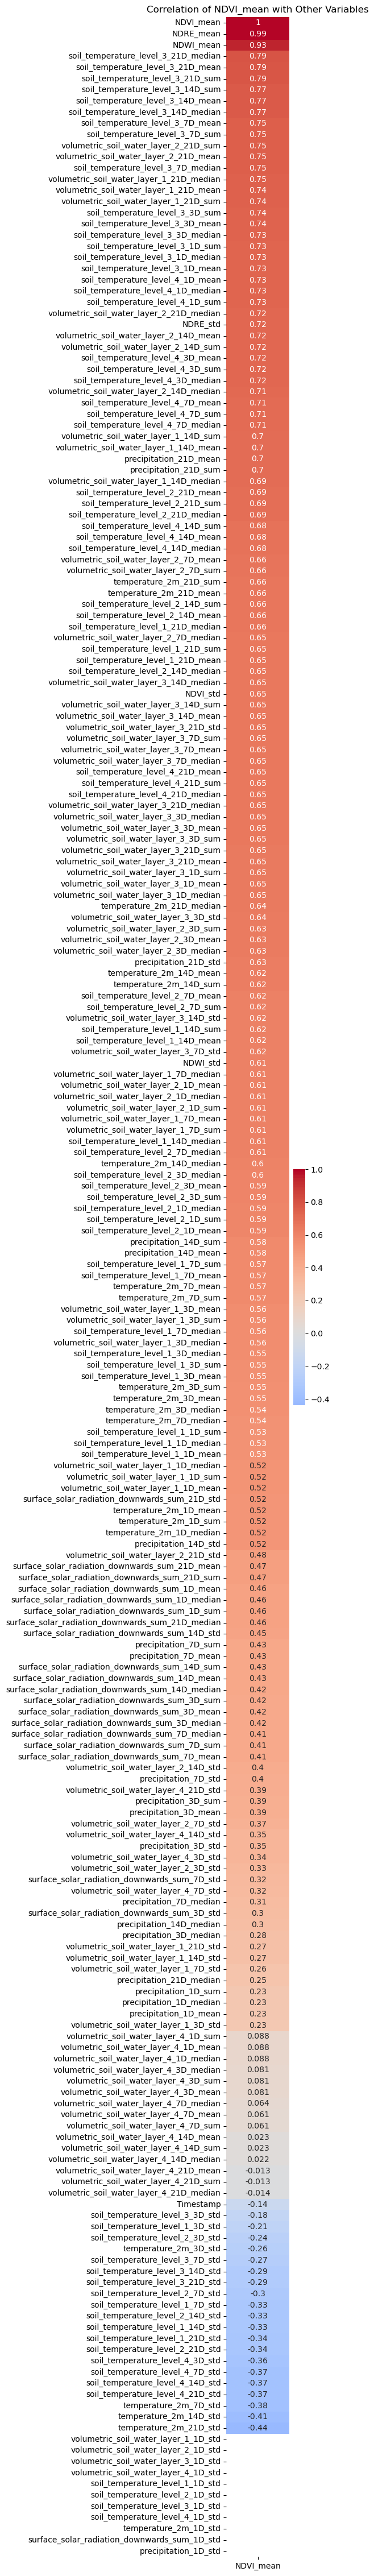

In [154]:
corr = rolling_master.corr()[["NDVI_mean"]].sort_values(by="NDVI_mean", ascending=False)
plt.figure(figsize=(6, len(corr) * 0.2))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation of NDVI_mean with Other Variables")
plt.tight_layout()
plt.show()

### Analyzing `soil_temperature_level_3`

To understand the relationship between `soil_temperature_level_3` and `NDVI_mean` further, we first check to see whether NDVI is leading or lagging.
To do this, we lag soil temperature either a few days into the past or into the future. Afterwards, the correlation between the lagged variable and `NDVI_mean` is calculated. To interpret this variable, let $p \ \epsilon \ \{-21, -14, -7, -3, -1, 0, 1, 3, 7, 14, 21\}$:
- $p > 0$: This suggest *past* soil temperature has an effect on NDVI.
- $p = 0$: This suggest only the *current* day soil temperate effects NDVI.
- $p < 0$: This suggests *future* soil temperature has an effect on current NDVI. This is the most unlikely scenario, and if this has high correlation it suggests that both NDVI and soil temperature are being effected by a different environmental variable.


In [165]:
soil_temp_3 = master_df[["Timestamp", "soil_temperature_level_3"]].copy()
periods = [-21, -14, -7, -3, -1, 0, 1, 3, 7, 14, 21]
slt_lag_df = engineering.lag_col(soil_temp_3, "soil_temperature_level_3", periods)
slt_lag_df.head()

correlations = []
for p in periods:
    column = f"soil_temperature_level_3_lag_{p}"
    corr = master_df["NDVI_mean"].corr(slt_lag_df[column])
    correlations.append(corr)

max_index = np.argmax(correlations)
max_lag = periods[max_index]
max_corr = correlations[max_index]

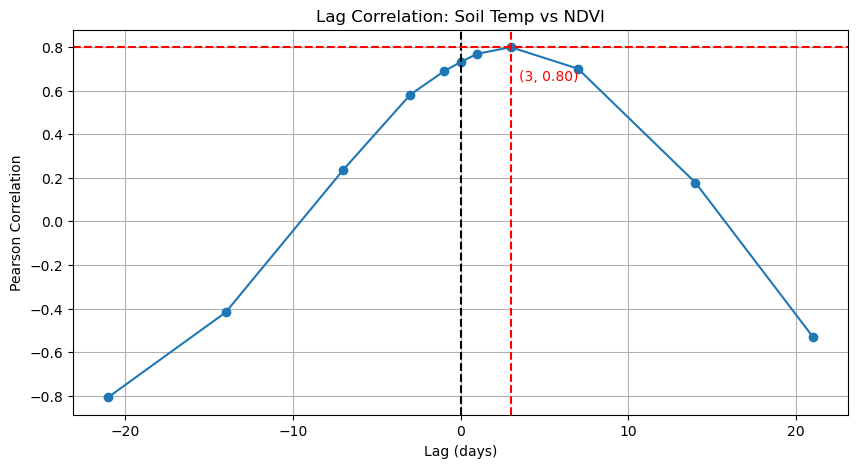

In [166]:
plt.figure(figsize=(10, 5))
plt.plot(periods, correlations, marker='o')
plt.axvline(0, color='black', linestyle='--')
plt.axvline(max_lag, color = 'red', linestyle='--')
plt.axhline(max_corr, color = 'red', linestyle='--')
plt.text(max_lag + 0.5, max_corr-0.15, f"({max_lag}, {max_corr:.2f})", color='red', fontsize=10)
plt.title('Lag Correlation: Soil Temp vs NDVI')
plt.xlabel('Lag (days)')
plt.ylabel('Pearson Correlation')
plt.grid(True)
plt.show()

,Timestamp,NDVI_mean,stl3_lag_3,soil_temperature_level_3_21D_mean,soil_temperature_level_3_21D_std,soil_temperature_level_3_21D_sum,soil_temperature_level_3_21D_median
0,2021-02-10,0.673053,NaN,NaN,NaN,NaN,NaN
1,2021-02-20,0.654526,NaN,NaN,NaN,NaN,NaN
2,2021-03-02,0.594535,NaN,NaN,NaN,NaN,NaN
3,2021-03-07,0.626770,292.099834,NaN,NaN,NaN,NaN
4,2021-03-12,0.550777,292.514029,NaN,NaN,NaN,NaN


A _positive_ lag of 3 days yields the highest correlation with NDVI. This suggests soil temperature at level 3 **leads** NDVI by 3 days. Therefore, we can now safely say:
- A rolling average of 21 days of level 3 soil temperature
- A 3 day positive lag of level 3 soil  temperature

are both complementary features that will be used in the final ML model.

In [ ]:
all_features = pd.DataFrame(master_df[["Timestamp", "NDVI_mean"]])
all_features["stl3_lag_3"] = slt_lag_df["soil_temperature_level_3_lag_3"]
stl3_rolling_stats = engineering.add_rolling_statistics(soil_temp_3, [21])
all_features = all_features.merge(stl3_rolling_stats, on ="Timestamp")
all_features.head()

np.float64(0.7645581574346539)

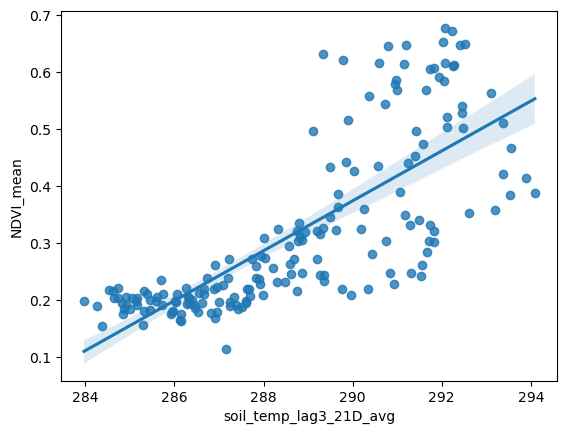

In [178]:
all_features["soil_temp_lag3_21D_avg"] = (all_features["stl3_lag_3"] + all_features["soil_temperature_level_3_21D_mean"]) / 2
sns.regplot(data=all_features,x="soil_temp_lag3_21D_avg", y="NDVI_mean")
all_features["soil_temp_lag3_21D_avg"].corr(all_features["NDVI_mean"])

# Time-series visualisation

## NDVI Mean per DOY

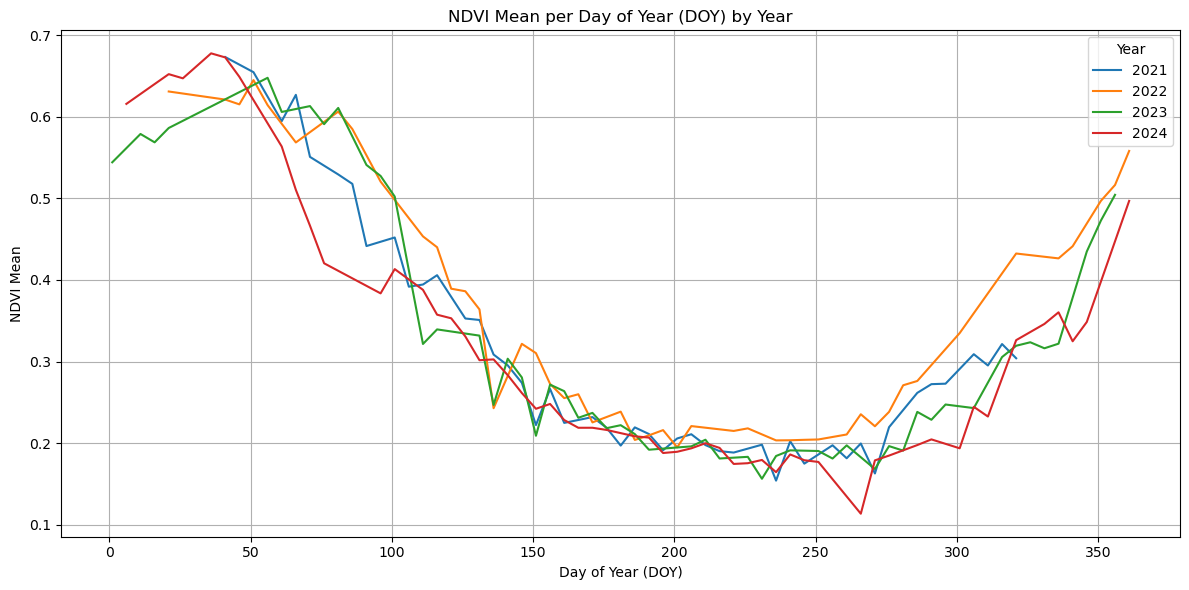

In [83]:
doy_df = grouped_spectral_df.copy()
doy_df["DOY"] = grouped_spectral_df["Timestamp"].dt.dayofyear
doy_df["Year"]=pd.DatetimeIndex(grouped_spectral_df["Timestamp"]).year
index_plotter.plot_index_doy_barchart(doy_df, indices.NDVI)